<a href="https://colab.research.google.com/github/mehrabbzz/Computer-Vision-Learning/blob/main/Manual_Feature_Extraction_with_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Extract Multiple features from a directory

In [ ]:
import PIL
import tqdm
import os
import numpy as np
import pandas as pd
import pickletools
import matplotlib.pyplot as plt
from torchvision import datasets
from skimage.filters import gabor
from skimage.feature import local_binary_pattern
from skimage import io, measure, color
from skimage.filters import threshold_otsu
from skimage.feature import local_binary_pattern
from skimage.filters import gabor
from skimage.measure import shannon_entropy
from PIL import Image
from scipy.stats import kurtosis, skew

In [ ]:
# Directory and paths
dirr1 = '/content/drive/MyDrive/Brain_Cancer/brain_glioma'  # Source folder
csv = '/content/Brain_Cancer.csv'  # Path to save CSV
c = 0  # Class label (0, 1, 2, ....)

# Initialize DataFrame
df1 = pd.DataFrame(columns=['class', 'Area', 'ConvexArea', 'Solidity',
                            'Shannon_Entropy', 'lbp_energy', 'lbp_entropy', 'gabor_energy', 'gabor_entropy'])

black = 0
j = 0
onlyfiles = next(os.walk(dirr1))[2]
print(f'Total images: {len(onlyfiles)}')

# Process each image
for i in os.listdir(dirr1):
    path = os.path.join(dirr1, i)
    print(f'Working on image: {i}')
    try:
        # Calculate Area
        image = io.imread(path, as_gray=True)
        thresh = threshold_otsu(image)
        binary = image > thresh
        area = np.sum(binary)

        # Calculate Convex Area and Solidity
        props = measure.regionprops(binary.astype(int))
        convex_area = round(props[0].convex_area, 4) if props else 0
        solidity = round(area / convex_area, 4) if convex_area != 0 else 0

        # Shannon Entropy
        sha_entropy = round(shannon_entropy(image), 4)

        # LBP Features
        image_uint8 = (image * 255).astype(np.uint8)
        feat_lbp = local_binary_pattern(image_uint8, P=8, R=1, method='uniform')
        lbp_hist, _ = np.histogram(feat_lbp, bins=8, range=(0, 8))
        lbp_prob = lbp_hist / np.sum(lbp_hist)
        lbp_energy = np.sum(lbp_prob ** 2)
        lbp_entropy = -np.sum(lbp_prob * np.log2(lbp_prob + 1e-9))

        # Gabor Features
        gabor_real, gabor_imag = gabor(image, frequency=0.6)
        gabor_magnitude = (gabor_real**2 + gabor_imag**2) / 2
        gabor_hist, _ = np.histogram(gabor_magnitude, bins=8)
        gabor_prob = gabor_hist / np.sum(gabor_hist)
        gabor_energy = np.sum(gabor_prob ** 2)
        gabor_entropy = -np.sum(gabor_prob * np.log2(gabor_prob + 1e-9))

        # Append to DataFrame
        df1.loc[j] = {
            'class': c,
            'Area': area,
            'ConvexArea': convex_area,
            'Solidity': solidity,
            'Shannon_Entropy': sha_entropy,
            'lbp_energy': lbp_energy,
            'lbp_entropy': lbp_entropy,
            'gabor_energy': gabor_energy,
            'gabor_entropy': gabor_entropy
        }
        j += 1

    except Exception as e:
        print(f'Error processing image {i}: {e}')
        black += 1
        continue

print(f'Black images found: {black} out of total images: {len(onlyfiles)}')

# Save to CSV
df1.to_csv(csv, index=False)
print('Feature extraction complete. Data saved to CSV.')


Total images: 2004
Working on image: brain_glioma_1010.jpg
Working on image: brain_glioma_1070.jpg
Working on image: brain_glioma_0987.jpg
Working on image: brain_glioma_0937.jpg
Working on image: brain_glioma_1048.jpg
Working on image: brain_glioma_0914.jpg
Working on image: brain_glioma_0941.jpg
Working on image: brain_glioma_0947.jpg
Working on image: brain_glioma_1074.jpg
Working on image: brain_glioma_1000.jpg
Working on image: brain_glioma_0992.jpg
Working on image: brain_glioma_0933.jpg
Working on image: brain_glioma_0996.jpg
Working on image: brain_glioma_0899.jpg
Working on image: brain_glioma_1043.jpg
Working on image: brain_glioma_1008.jpg
Working on image: brain_glioma_0998.jpg
Working on image: brain_glioma_1040.jpg
Working on image: brain_glioma_0980.jpg
Working on image: brain_glioma_0902.jpg
Working on image: brain_glioma_0918.jpg
Working on image: brain_glioma_0876.jpg
Working on image: brain_glioma_0911.jpg
Working on image: brain_glioma_0951.jpg
Working on image: bra

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Brain_Cancer.csv')
df

,class,Area,ConvexArea,Solidity,Shannon_Entropy,lbp_energy,lbp_entropy,gabor_energy,gabor_entropy
0,0,111703,134029.0,0.8334,5.2885,0.345267,2.027034,0.940592,0.219816
1,0,94267,155077.0,0.6079,5.7539,0.240545,2.372619,0.907870,0.327801
2,0,93006,126415.0,0.7357,5.9253,0.256798,2.305417,0.903898,0.345718
3,0,109819,132665.0,0.8278,5.1232,0.328795,2.092554,0.952552,0.188199
4,0,87242,89948.0,0.9699,4.0467,0.483416,1.634483,0.911127,0.324981
...,...,...,...,...,...,...,...,...,...
1999,0,106822,123280.0,0.8665,4.9162,0.358104,1.995604,0.980333,0.088538
2000,0,59714,82574.0,0.7232,3.0833,0.550240,1.452138,0.993358,0.035150
2001,0,90863,100530.0,0.9038,4.1984,0.404899,1.864741,0.892262,0.387008
2002,0,117841,140282.0,0.8400,5.8556,0.254655,2.321928,0.950978,0.188441


In [ ]:
df

,class,Area,ConvexArea,Solidity,Shannon_Entropy,lbp_energy,lbp_entropy,gabor_energy,gabor_entropy
0,0,111703,134029.0,0.8334,5.2885,0.345267,2.027034,0.940592,0.219816
1,0,94267,155077.0,0.6079,5.7539,0.240545,2.372619,0.907870,0.327801
2,0,93006,126415.0,0.7357,5.9253,0.256798,2.305417,0.903898,0.345718
3,0,109819,132665.0,0.8278,5.1232,0.328795,2.092554,0.952552,0.188199
4,0,87242,89948.0,0.9699,4.0467,0.483416,1.634483,0.911127,0.324981
...,...,...,...,...,...,...,...,...,...
1999,0,106822,123280.0,0.8665,4.9162,0.358104,1.995604,0.980333,0.088538
2000,0,59714,82574.0,0.7232,3.0833,0.550240,1.452138,0.993358,0.035150
2001,0,90863,100530.0,0.9038,4.1984,0.404899,1.864741,0.892262,0.387008
2002,0,117841,140282.0,0.8400,5.8556,0.254655,2.321928,0.950978,0.188441


In [ ]:
# Directory and paths
dirr2 = '/content/drive/MyDrive/Brain_Cancer/brain_menin'  # Source folder
csv = '/content/Brain_menin.csv'  # Path to save CSV
c = 1  # Class label (0, 1, 2, ....)

# Initialize DataFrame
df2 = pd.DataFrame(columns=['class', 'Area', 'ConvexArea', 'Solidity',
                            'Shannon_Entropy', 'lbp_energy', 'lbp_entropy', 'gabor_energy', 'gabor_entropy'])

black = 0
j = 0
onlyfiles = next(os.walk(dirr2))[2]
print(f'Total images: {len(onlyfiles)}')

# Process each image
for i in os.listdir(dirr2):
    path = os.path.join(dirr2, i)
    print(f'Working on image: {i}')
    try:
        # Calculate Area
        image = io.imread(path, as_gray=True)
        thresh = threshold_otsu(image)
        binary = image > thresh
        area = np.sum(binary)

        # Calculate Convex Area and Solidity
        props = measure.regionprops(binary.astype(int))
        convex_area = round(props[0].convex_area, 4) if props else 0
        solidity = round(area / convex_area, 4) if convex_area != 0 else 0

        # Shannon Entropy
        sha_entropy = round(shannon_entropy(image), 4)

        # LBP Features
        image_uint8 = (image * 255).astype(np.uint8)
        feat_lbp = local_binary_pattern(image_uint8, P=8, R=1, method='uniform')
        lbp_hist, _ = np.histogram(feat_lbp, bins=8, range=(0, 8))
        lbp_prob = lbp_hist / np.sum(lbp_hist)
        lbp_energy = np.sum(lbp_prob ** 2)
        lbp_entropy = -np.sum(lbp_prob * np.log2(lbp_prob + 1e-9))

        # Gabor Features
        gabor_real, gabor_imag = gabor(image, frequency=0.6)
        gabor_magnitude = (gabor_real**2 + gabor_imag**2) / 2
        gabor_hist, _ = np.histogram(gabor_magnitude, bins=8)
        gabor_prob = gabor_hist / np.sum(gabor_hist)
        gabor_energy = np.sum(gabor_prob ** 2)
        gabor_entropy = -np.sum(gabor_prob * np.log2(gabor_prob + 1e-9))

        # Append to DataFrame
        df2.loc[j] = {
            'class': c,
            'Area': area,
            'ConvexArea': convex_area,
            'Solidity': solidity,
            'Shannon_Entropy': sha_entropy,
            'lbp_energy': lbp_energy,
            'lbp_entropy': lbp_entropy,
            'gabor_energy': gabor_energy,
            'gabor_entropy': gabor_entropy
        }
        j += 1

    except Exception as e:
        print(f'Error processing image {i}: {e}')
        black += 1
        continue

print(f'Black images found: {black} out of total images: {len(onlyfiles)}')

# Save to CSV
df2.to_csv(csv, index=False)
print('Feature extraction complete. Data saved to CSV.')


Total images: 2004
Working on image: brain_menin_1049.jpg
Working on image: brain_menin_1071.jpg
Working on image: brain_menin_1103.jpg
Working on image: brain_menin_0988.jpg
Working on image: brain_menin_0975.jpg
Working on image: brain_menin_0987.jpg
Working on image: brain_menin_0985.jpg
Working on image: brain_menin_1098.jpg
Working on image: brain_menin_1133.jpg
Working on image: brain_menin_0952.jpg
Working on image: brain_menin_1042.jpg
Working on image: brain_menin_1035.jpg
Working on image: brain_menin_0990.jpg
Working on image: brain_menin_1059.jpg
Working on image: brain_menin_0947.jpg
Working on image: brain_menin_1064.jpg
Working on image: brain_menin_0964.jpg
Working on image: brain_menin_0939.jpg
Working on image: brain_menin_1125.jpg
Working on image: brain_menin_0960.jpg
Working on image: brain_menin_1052.jpg
Working on image: brain_menin_1134.jpg
Working on image: brain_menin_0989.jpg
Working on image: brain_menin_0981.jpg
Working on image: brain_menin_0955.jpg
Workin

In [ ]:
import pandas as pd

df2 = pd.read_csv('/content/Brain_menin.csv')
df2

,class,Area,ConvexArea,Solidity,Shannon_Entropy,lbp_energy,lbp_entropy,gabor_energy,gabor_entropy
0,1,135545,176134.0,0.7696,6.4723,0.223157,2.408360,0.834728,0.535494
1,1,110178,135260.0,0.8146,5.7491,0.292517,2.172193,0.832057,0.536627
2,1,151281,199874.0,0.7569,6.4525,0.213474,2.448757,0.948757,0.208595
3,1,76651,81324.0,0.9425,4.2760,0.379506,1.943744,0.824297,0.581067
4,1,75923,87704.0,0.8657,3.9551,0.496037,1.604726,0.965097,0.149823
...,...,...,...,...,...,...,...,...,...
1999,1,117395,151384.0,0.7755,6.3723,0.228319,2.387411,0.794740,0.671440
2000,1,120893,156874.0,0.7706,6.4135,0.217876,2.452340,0.851915,0.481933
2001,1,91131,113213.0,0.8050,5.0105,0.368798,1.959760,0.921360,0.284851
2002,1,102268,124317.0,0.8226,5.5562,0.287889,2.189443,0.926456,0.274199


In [ ]:
# Directory and paths
dirr3 = '/content/drive/MyDrive/Brain_Cancer/brain_tumor'  # Source folder
csv = '/content/Brain_tumor.csv'  # Path to save CSV
c = 2  # Class label (0, 1, 2, ....)

# Initialize DataFrame
df3 = pd.DataFrame(columns=['class', 'Area', 'ConvexArea', 'Solidity',
                            'Shannon_Entropy', 'lbp_energy', 'lbp_entropy', 'gabor_energy', 'gabor_entropy'])

black = 0
j = 0
onlyfiles = next(os.walk(dirr3))[2]
print(f'Total images: {len(onlyfiles)}')

# Process each image
for i in os.listdir(dirr3):
    path = os.path.join(dirr3, i)
    print(f'Working on image: {i}')
    try:
        # Calculate Area
        image = io.imread(path, as_gray=True)
        thresh = threshold_otsu(image)
        binary = image > thresh
        area = np.sum(binary)

        # Calculate Convex Area and Solidity
        props = measure.regionprops(binary.astype(int))
        convex_area = round(props[0].convex_area, 4) if props else 0
        solidity = round(area / convex_area, 4) if convex_area != 0 else 0

        # Shannon Entropy
        sha_entropy = round(shannon_entropy(image), 4)

        # LBP Features
        image_uint8 = (image * 255).astype(np.uint8)
        feat_lbp = local_binary_pattern(image_uint8, P=8, R=1, method='uniform')
        lbp_hist, _ = np.histogram(feat_lbp, bins=8, range=(0, 8))
        lbp_prob = lbp_hist / np.sum(lbp_hist)
        lbp_energy = np.sum(lbp_prob ** 2)
        lbp_entropy = -np.sum(lbp_prob * np.log2(lbp_prob + 1e-9))

        # Gabor Features
        gabor_real, gabor_imag = gabor(image, frequency=0.6)
        gabor_magnitude = (gabor_real**2 + gabor_imag**2) / 2
        gabor_hist, _ = np.histogram(gabor_magnitude, bins=8)
        gabor_prob = gabor_hist / np.sum(gabor_hist)
        gabor_energy = np.sum(gabor_prob ** 2)
        gabor_entropy = -np.sum(gabor_prob * np.log2(gabor_prob + 1e-9))

        # Append to DataFrame
        df3.loc[j] = {
            'class': c,
            'Area': area,
            'ConvexArea': convex_area,
            'Solidity': solidity,
            'Shannon_Entropy': sha_entropy,
            'lbp_energy': lbp_energy,
            'lbp_entropy': lbp_entropy,
            'gabor_energy': gabor_energy,
            'gabor_entropy': gabor_entropy
        }
        j += 1

    except Exception as e:
        print(f'Error processing image {i}: {e}')
        black += 1
        continue

print(f'Black images found: {black} out of total images: {len(onlyfiles)}')

# Save to CSV
df3.to_csv(csv, index=False)
print('Feature extraction complete. Data saved to CSV.')


Total images: 2048
Working on image: brain_tumor_1043.jpg
Working on image: brain_tumor_1101.jpg
Working on image: brain_tumor_0970.jpg
Working on image: brain_tumor_1046.jpg
Working on image: brain_tumor_1097.jpg
Working on image: brain_tumor_1068.jpg
Working on image: brain_tumor_0989.jpg
Working on image: brain_tumor_1008.jpg
Working on image: brain_tumor_1005.jpg
Working on image: brain_tumor_1067.jpg
Working on image: brain_tumor_1065.jpg
Working on image: brain_tumor_1078.jpg
Working on image: brain_tumor_1072.jpg
Working on image: brain_tumor_0958.jpg
Working on image: brain_tumor_1029.jpg
Working on image: brain_tumor_1069.jpg
Working on image: brain_tumor_0979.jpg
Working on image: brain_tumor_1136.jpg
Working on image: brain_tumor_1089.jpg
Working on image: brain_tumor_1057.jpg
Working on image: brain_tumor_0971.jpg
Working on image: brain_tumor_1113.jpg
Working on image: brain_tumor_0974.jpg
Working on image: brain_tumor_1020.jpg
Working on image: brain_tumor_0982.jpg
Workin

In [ ]:
df3 = pd.read_csv('/content/Brain_tumor.csv')
df3

,class,Area,ConvexArea,Solidity,Shannon_Entropy,lbp_energy,lbp_entropy,gabor_energy,gabor_entropy
0,2,117509,138847.0,0.8463,6.4419,0.198076,2.537755,0.837615,0.529474
1,2,130767,191461.0,0.6830,6.7318,0.193544,2.560957,0.845756,0.543451
2,2,116590,149506.0,0.7798,5.7901,0.225919,2.439683,0.935854,0.244086
3,2,109573,160843.0,0.6812,6.4193,0.198820,2.540856,0.929844,0.270897
4,2,128321,194771.0,0.6588,6.4640,0.208561,2.456010,0.921450,0.306829
...,...,...,...,...,...,...,...,...,...
2043,2,142306,183186.0,0.7768,6.2830,0.195388,2.538528,0.924790,0.269903
2044,2,117086,142787.0,0.8200,6.2682,0.220533,2.462278,0.866952,0.455652
2045,2,167483,200106.0,0.8370,6.5972,0.219234,2.396678,0.907199,0.339877
2046,2,128720,159867.0,0.8052,6.2748,0.208566,2.503727,0.817782,0.562400


In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/Brain_glioma.csv')
df2 = pd.read_csv('/content/drive/MyDrive/Brain_menin.csv')
df3 = pd.read_csv('/content/drive/MyDrive/Brain_tumor.csv')

In [ ]:
import pandas as pd

# Merge the two DataFrames (row-wise)
merged_df = pd.concat([df1, df2, df3], ignore_index=True)

# Save the merged DataFrame to a new CSV
merged_df.to_csv('/content/Merged_file.csv', index=False)

print("Merging completed and saved as 'Merged_file.csv'")

Merging completed and saved as 'Merged_file.csv'


In [ ]:
df = pd.read_csv('/content/Merged_file.csv')
df

,class,Area,ConvexArea,Solidity,Shannon_Entropy,lbp_energy,lbp_entropy,gabor_energy,gabor_entropy
0,0,111703,134029.0,0.8334,5.2885,0.345267,2.027034,0.940592,0.219816
1,0,94267,155077.0,0.6079,5.7539,0.240545,2.372619,0.907870,0.327801
2,0,93006,126415.0,0.7357,5.9253,0.256798,2.305417,0.903898,0.345718
3,0,109819,132665.0,0.8278,5.1232,0.328795,2.092554,0.952552,0.188199
4,0,87242,89948.0,0.9699,4.0467,0.483416,1.634483,0.911127,0.324981
...,...,...,...,...,...,...,...,...,...
6051,2,142306,183186.0,0.7768,6.2830,0.195388,2.538528,0.924790,0.269903
6052,2,117086,142787.0,0.8200,6.2682,0.220533,2.462278,0.866952,0.455652
6053,2,167483,200106.0,0.8370,6.5972,0.219234,2.396678,0.907199,0.339877
6054,2,128720,159867.0,0.8052,6.2748,0.208566,2.503727,0.817782,0.562400


# Suffle the dataset

In [ ]:
from sklearn.utils import shuffle

df = shuffle(df, random_state=42)

In [ ]:
df.columns

Index(['class', 'Area', 'ConvexArea', 'Solidity', 'Shannon_Entropy',
       'lbp_energy', 'lbp_entropy', 'gabor_energy', 'gabor_entropy'],
      dtype='object')

In [ ]:
X= df.drop(['class'],axis='columns')
y=df['class']

Scale the features


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)  # learn scaling from all data (or just train later)

In [ ]:
X_df = pd.DataFrame(X_scaled, columns=df.columns[1:])
X_df.head(10)  # show first 10 rows

,Area,ConvexArea,Solidity,Shannon_Entropy,lbp_energy,lbp_entropy,gabor_energy,gabor_entropy
0,-0.033036,-0.276947,0.594399,-0.686891,0.222913,-0.193271,1.368473,-1.467265
1,0.089166,0.700737,-1.578919,0.848373,-1.138800,1.266436,0.582176,-0.505021
2,0.022781,-0.379468,1.071697,-1.359146,1.085993,-1.097693,0.161052,-0.132455
3,0.063930,0.086648,-0.218082,-0.286789,-0.129953,0.086027,0.692383,-0.627038
4,0.706082,0.458005,0.247150,0.277228,-0.289200,0.246410,-0.106477,0.127944
5,1.002485,0.951929,-0.310592,0.998703,-1.184413,1.393051,0.166882,-0.162013
6,-0.387706,-0.824895,1.551678,-0.880873,0.864328,-0.923579,0.962380,-0.979373
7,-1.634157,-1.212138,-0.960844,-1.447563,1.628589,-1.549643,-0.290736,0.239361
8,0.748075,0.896565,-0.681973,0.855611,-0.806073,0.714955,-0.389289,0.531570
9,-0.307739,-0.502620,0.601102,-0.466183,0.362719,-0.387357,1.279898,-1.345529


In [ ]:
X = df.drop(['class'],axis='columns')
y = df['class']

# Stratified split

In [ ]:
from sklearn.model_selection import train_test_split

# X = features, y = labels
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [ ]:
X_train.shape

(4239, 8)

In [ ]:
y_train.shape

(4239,)

In [ ]:
from tensorflow import keras

# Defining the model
model = keras.Sequential([
    keras.layers.Input(shape=(8,)),  # Input layer with 8 features to match X_train
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),  # First hidden layer with 26 neurons
    keras.layers.Dense(16, activation='relu'),  # Second hidden layer with 15 neurons
    keras.layers.Dense(3, activation='softmax')  # Output layer with softmax for multiclass classification
])

# Compile the model
model.compile(optimizer='adam',  # Adam optimizer
              loss = 'sparse_categorical_crossentropy',  # Loss function for multiclass classification
              metrics=['accuracy'])  # Metric to evaluate accuracy

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
# Fit the model with training data and save the history
history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_split=0.2)  # Training the model with validation split

Epoch 1/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6237 - loss: 0.8064 - val_accuracy: 0.7123 - val_loss: 0.6798
Epoch 2/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7455 - loss: 0.6251 - val_accuracy: 0.7594 - val_loss: 0.5899
Epoch 3/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7635 - loss: 0.5743 - val_accuracy: 0.7559 - val_loss: 0.5617
Epoch 4/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7774 - loss: 0.5477 - val_accuracy: 0.7783 - val_loss: 0.5437
Epoch 5/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7835 - loss: 0.5310 - val_accuracy: 0.7818 - val_loss: 0.5366
Epoch 6/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7859 - loss: 0.5196 - val_accuracy: 0.7795 - val_loss: 0.5186
Epoch 7/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7883 - loss: 0.5144 - val_accuracy: 0.7936 - val_loss: 0.5104
Epoch 8/200
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7909 - loss: 0.5066 - val_accu

In [ ]:
# Save the model weights
model.save_weights('/content/model_weights.weights.h5')

# Save the training and validation accuracy and loss in a CSV file
history_df = pd.DataFrame(history.history)
history_df.to_csv('/content/training_history.csv', index=False)

In [ ]:
# Load model weights
model.load_weights('/content/model_weights.weights.h5')

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

# Print the test accuracy
print(f'Test Accuracy: {test_accuracy}')

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8196 - loss: 0.4691 
Test Accuracy: 0.8195819854736328


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


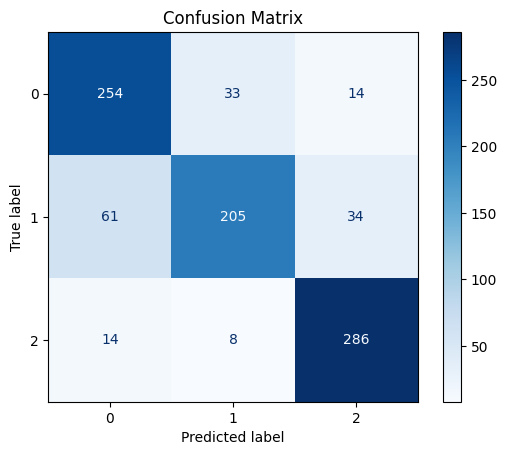

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Generate predictions
y_pred_probs = model.predict(X_test)          # Output is probabilities for each class
y_pred = np.argmax(y_pred_probs, axis=1)      # Pick class with highest probability

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix')
plt.show()

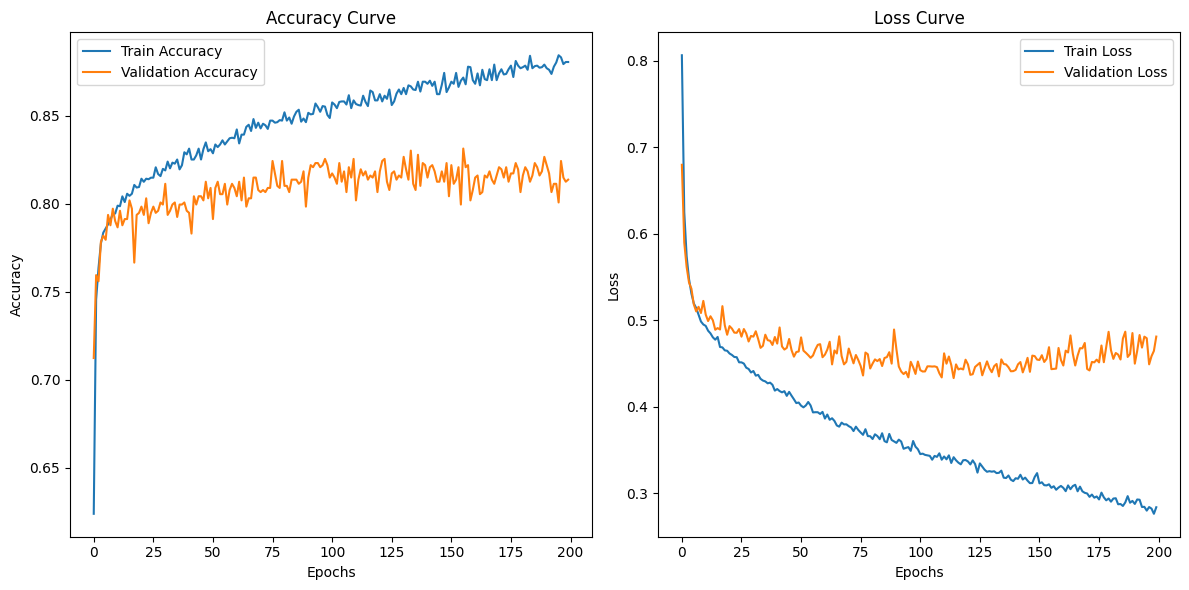

In [ ]:
# Plot accuracy curve
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()